# Error Analysis By Model and Dataset


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

In [53]:
# Load both result files
bedrock_path = "../results/synthetic_groundedness_challenger_set_bedrock_results.csv"
llm_path = "../results/synthetic_groundedness_challenger_set_llm_results.csv"

bedrock_df = pd.read_csv(bedrock_path)
llm_df = pd.read_csv(llm_path)

# Merge on (query, context, response, label) which uniquely define a test case
merged_results = pd.merge(
    llm_df,
    bedrock_df,
    on=["query", "context", "response", "label"],
    how="inner",
    suffixes=("_llm", "_bedrock")
)

merged_results["label"] = merged_results["label"].str.upper().map({"PASS": 1, "FAIL": 0})
merged_results


,query,context,response,label,llm_score,llm_reasoning,bedrock_action,grounding_score,grounding_threshold,grounding_decision_reason,blocked_output_text
0,I made a big purchase that I regretted and can...,### Refund Not Showing Up? Here's What You Nee...,"To verify your refund, please follow these ste...",1,PASS,The ANSWER provides steps to verify the refund...,NONE,NaN,NaN,NaN,NaN
1,I am still waiting to find out the status of m...,**Refund Status Inquiry**\n\nWe understand tha...,We understand that waiting for a refund can be...,1,PASS,The ANSWER closely follows the steps outlined ...,NONE,NaN,NaN,NaN,NaN
2,"As advised by you, i requested seller to refun...",### Refund Status Inquiry\n\nThank you for rea...,Thank you for reaching out to us regarding you...,1,PASS,The ANSWER closely follows the guidance provid...,NONE,NaN,NaN,NaN,NaN
3,"Hurry and refund me, I am waiting",### Refund Not Showing Up\n\nWe understand tha...,We understand that waiting for a refund can be...,1,PASS,The ANSWER accurately reflects the information...,NONE,NaN,NaN,NaN,NaN
4,I was supposed to get a refund but I do not se...,**FAQ: My Refund is Not Showing Up**\n\nIf you...,If you are expecting a refund but do not see i...,1,PASS,The ANSWER provides steps to follow if a refun...,NONE,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
765,The wrong exchange rate was used for my cash w...,**Help & FAQs: Exchange Rates for Cash Withdra...,I apologize if you encountered any discrepanci...,0,PASS,The ANSWER acknowledges potential discrepancie...,GUARDRAIL_INTERVENED,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
766,Can i get money in my home currency at my ATM ...,### Can I Withdraw Cash in My Home Currency at...,Can i get money in my home currency at my ATM?...,0,FAIL,The DOCUMENT states that ATMs do not offer the...,NONE,NaN,NaN,NaN,NaN
767,The exchange rate applied was incorrect when I...,**Exchange Rates for Cash Withdrawals While Tr...,I understand that you noticed the exchange rat...,0,FAIL,The DOCUMENT discusses exchange rates for cash...,GUARDRAIL_INTERVENED,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
768,I exchanged cash when traveling and the rate w...,**Help Section: Currency Exchange Rates for Ca...,I'm sorry to hear that you experienced an issu...,0,FAIL,The ANSWER introduces the concept of a 'Platin...,GUARDRAIL_INTERVENED,NaN,NaN,NaN,"Sorry, the model cannot answer this question."


In [54]:
# Load the two files
example_path = "../results/retailbank_example_df.csv"
test_path = "../results/retailbankQA_test.csv"

example_df = pd.read_csv(example_path)
test_df = pd.read_csv(test_path)

example_df = example_df.drop(columns=["source_ds", "source"])
# Merge on a common key — assuming "test_case_id" in example_df corresponds to "id" in test_df
merged_df = pd.merge(example_df, test_df, left_on="test_case_id", right_on="id", how="left")
merged_df

,test_case_id,chunk_id,pred_prob,pred_label,max_pred_prob,example_pred_label,true_label,id,context,query,response,label,source_ds,source
0,retailbankQA_test_0,0_0,0.998359,1,0.998359,1,1,retailbankQA_test_0,### Refund Not Showing Up? Here's What You Nee...,I made a big purchase that I regretted and can...,"To verify your refund, please follow these ste...",1,retailbankQA_test,retailbankQA_test
1,retailbankQA_test_1,1_0,0.026392,0,0.994920,1,1,retailbankQA_test_1,**Refund Status Inquiry**\n\nWe understand tha...,I am still waiting to find out the status of m...,We understand that waiting for a refund can be...,1,retailbankQA_test,retailbankQA_test
2,retailbankQA_test_2,2_0,0.994479,1,0.994772,1,1,retailbankQA_test_2,### Refund Status Inquiry\n\nThank you for rea...,"As advised by you, i requested seller to refun...",Thank you for reaching out to us regarding you...,1,retailbankQA_test,retailbankQA_test
3,retailbankQA_test_3,3_0,0.994941,1,0.994941,1,1,retailbankQA_test_3,### Refund Not Showing Up\n\nWe understand tha...,"Hurry and refund me, I am waiting",We understand that waiting for a refund can be...,1,retailbankQA_test,retailbankQA_test
4,retailbankQA_test_4,4_0,0.998551,1,0.998551,1,1,retailbankQA_test_4,**FAQ: My Refund is Not Showing Up**\n\nIf you...,I was supposed to get a refund but I do not se...,If you are expecting a refund but do not see i...,1,retailbankQA_test,retailbankQA_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,retailbankQA_test_765,765_0,0.000652,0,0.000717,0,0,retailbankQA_test_765,**Help & FAQs: Exchange Rates for Cash Withdra...,The wrong exchange rate was used for my cash w...,I apologize if you encountered any discrepanci...,0,retailbankQA_test,retailbankQA_test
766,retailbankQA_test_766,766_0,0.000688,0,0.000719,0,0,retailbankQA_test_766,### Can I Withdraw Cash in My Home Currency at...,Can i get money in my home currency at my ATM ...,Can i get money in my home currency at my ATM?...,0,retailbankQA_test,retailbankQA_test
767,retailbankQA_test_767,767_0,0.000529,0,0.000529,0,0,retailbankQA_test_767,**Exchange Rates for Cash Withdrawals While Tr...,The exchange rate applied was incorrect when I...,I understand that you noticed the exchange rat...,0,retailbankQA_test,retailbankQA_test
768,retailbankQA_test_768,768_0,0.000525,0,0.000525,0,0,retailbankQA_test_768,**Help Section: Currency Exchange Rates for Ca...,I exchanged cash when traveling and the rate w...,I'm sorry to hear that you experienced an issu...,0,retailbankQA_test,retailbankQA_test


In [55]:
# Ensure all join columns are strings
join_keys = ["query", "context", "response", "label"]

for key in join_keys:
    merged_df[key] = merged_df[key].astype(str)
    merged_results[key] = merged_results[key].astype(str)

# Now safely merge
final_merged = pd.merge(
    merged_df,
    merged_results,
    on=join_keys,
    how="left"
)

final_merged

# Select relevant columns
columns_to_keep = [
    "test_case_id",
    "query",
    "context",
    "response",
    "llm_score",
    "bedrock_action",
    "true_label",
    "example_pred_label",
    "source_ds",
    "source"
]
final_retail = final_merged[columns_to_keep]

# Rename for clarity
final_retail.columns = [
    "test_case_id", "query", "context", "response",
    "llm_score", "bedrock_action", "true_label", "cross_encoder_pred", "source_ds", "source"
]

# Convert outcome columns to binary flags
final_retail["llm_score"] = final_retail["llm_score"].str.upper().map({"PASS": 1, "FAIL": 0})
final_retail["bedrock_action"] = final_retail["bedrock_action"].apply(lambda x: 1 if x == "NONE" else 0)

final_retail


C:\Users\tahle\AppData\Local\Temp\ipykernel_24144\3843102854.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_retail["llm_score"] = final_retail["llm_score"].str.upper().map({"PASS": 1, "FAIL": 0})
C:\Users\tahle\AppData\Local\Temp\ipykernel_24144\3843102854.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_retail["bedrock_action"] = final_retail["bedrock_action"].apply(lambda x: 1 if x == "NONE" else 0)


,test_case_id,query,context,response,llm_score,bedrock_action,true_label,cross_encoder_pred,source_ds,source
0,retailbankQA_test_0,I made a big purchase that I regretted and can...,### Refund Not Showing Up? Here's What You Nee...,"To verify your refund, please follow these ste...",1,1,1,1,retailbankQA_test,retailbankQA_test
1,retailbankQA_test_1,I am still waiting to find out the status of m...,**Refund Status Inquiry**\n\nWe understand tha...,We understand that waiting for a refund can be...,1,1,1,1,retailbankQA_test,retailbankQA_test
2,retailbankQA_test_2,"As advised by you, i requested seller to refun...",### Refund Status Inquiry\n\nThank you for rea...,Thank you for reaching out to us regarding you...,1,1,1,1,retailbankQA_test,retailbankQA_test
3,retailbankQA_test_3,"Hurry and refund me, I am waiting",### Refund Not Showing Up\n\nWe understand tha...,We understand that waiting for a refund can be...,1,1,1,1,retailbankQA_test,retailbankQA_test
4,retailbankQA_test_4,I was supposed to get a refund but I do not se...,**FAQ: My Refund is Not Showing Up**\n\nIf you...,If you are expecting a refund but do not see i...,1,1,1,1,retailbankQA_test,retailbankQA_test
...,...,...,...,...,...,...,...,...,...,...
765,retailbankQA_test_765,The wrong exchange rate was used for my cash w...,**Help & FAQs: Exchange Rates for Cash Withdra...,I apologize if you encountered any discrepanci...,1,0,0,0,retailbankQA_test,retailbankQA_test
766,retailbankQA_test_766,Can i get money in my home currency at my ATM ...,### Can I Withdraw Cash in My Home Currency at...,Can i get money in my home currency at my ATM?...,0,1,0,0,retailbankQA_test,retailbankQA_test
767,retailbankQA_test_767,The exchange rate applied was incorrect when I...,**Exchange Rates for Cash Withdrawals While Tr...,I understand that you noticed the exchange rat...,0,0,0,0,retailbankQA_test,retailbankQA_test
768,retailbankQA_test_768,I exchanged cash when traveling and the rate w...,**Help Section: Currency Exchange Rates for Ca...,I'm sorry to hear that you experienced an issu...,0,0,0,0,retailbankQA_test,retailbankQA_test


In [56]:
# Load the latest uploaded files
llm_path = "../results/halubench_llm_results.csv"
bedrock_path = "../results/halubench_bedrock_results.csv"
truth_path = "../results/halubench_example_df.csv"

llm_df = pd.read_csv(llm_path)
bedrock_df = pd.read_csv(bedrock_path)
truth_df = pd.read_csv(truth_path)

# Standardize column names for merge
llm_df = llm_df.rename(columns={"id": "test_case_id"})
bedrock_df = bedrock_df.rename(columns={"id": "test_case_id"})

# Merge all three dataframes on 'test_case_id'
merged = llm_df.merge(bedrock_df, on="test_case_id", suffixes=("_llm", "_bedrock"))
merged = merged.merge(truth_df, on="test_case_id", suffixes=("", "_truth"))

merged


,test_case_id,context_llm,query_llm,response_llm,label_llm,source_ds_llm,source_llm,llm_score,llm_reasoning,context_bedrock,...,grounding_decision_reason,blocked_output_text,chunk_id,pred_prob,pred_label,max_pred_prob,example_pred_label,true_label,source_ds,source
0,26104577,The prognostic importance of extramedullary in...,Does waldenström macroglobulinemia with extram...,Yes. We show that extramedullary involvement a...,0,pubmedQA,halubench,FAIL,The DOCUMENT states that EMWM patients had a s...,The prognostic importance of extramedullary in...,...,NaN,"Sorry, the model cannot answer this question.",1935_0,0.965447,1,0.965447,1,0,pubmedQA,halubench
1,financebench_id_02656,128 \nConsolidated Statements of Operations\nY...,What is the FY2019 - FY2021 3 year average of ...,75.1%,0,FinanceBench,halubench,FAIL,To calculate the COGS as a percentage of reven...,128 \nConsolidated Statements of Operations\nY...,...,NaN,NaN,2020_0,0.699952,1,0.788797,1,0,FinanceBench,halubench
2,financebench_id_08319,PART II\nItem 8\n \n \nBALANCE SHEETS\n \n(In ...,We need to calculate a reasonable approximatio...,"$364,850.00",0,FinanceBench,halubench,FAIL,The DOCUMENT provides the total assets for Mic...,PART II\nItem 8\n \n \nBALANCE SHEETS\n \n(In ...,...,NaN,"Sorry, the model cannot answer this question.",2069_0,0.552437,1,0.552437,1,0,FinanceBench,halubench
3,12135,passage 1:1 Spray a baking sheet with butter f...,how to cook pollock?,"Based on the provided passages, here is how to...",1,RAGTruth,halubench,FAIL,The ANSWER accurately summarizes the steps fro...,passage 1:1 Spray a baking sheet with butter f...,...,NaN,NaN,3039_0,0.881065,1,0.983435,1,1,RAGTruth,halubench
4,21442579,Intra-aortic balloon pump (IABP) is an establi...,Does intra-aortic balloon pump implantation af...,No. This study demonstrates that CABG with IAB...,1,pubmedQA,halubench,PASS,The DOCUMENT provides data on the survival rat...,Intra-aortic balloon pump (IABP) is an establi...,...,NaN,"Sorry, the model cannot answer this question.",1228_0,0.062358,0,0.173395,0,1,pubmedQA,halubench
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,financebench_id_05629,Table of Contents\n \n \nintel corporation\nco...,By relying on the line items plainly stated wi...,5.7%,1,FinanceBench,halubench,PASS,The DOCUMENT provides Intel's net revenue for ...,Table of Contents\n \n \nintel corporation\nco...,...,NaN,"Sorry, the model cannot answer this question.",2782_0,0.522880,1,0.522880,1,1,FinanceBench,halubench
580,9555b283-c5a8-467a-b0bd-84ca6bdd54c0,Hoping to rebound from their home loss to the...,Who got the Cardinals their first points of th...,Anquan Boldin,0,DROP,halubench,FAIL,The DOCUMENT states that the Cardinals scored ...,Hoping to rebound from their home loss to the...,...,NaN,"Sorry, the model cannot answer this question.",293_0,0.585103,1,0.585103,1,0,DROP,halubench
581,financebench_id_05288,"SQUARE,INC.\nCONSOLIDATEDSTATEMENTSOFOPERATION...",We need to calculate a reasonable approximatio...,-4.5%,1,FinanceBench,halubench,PASS,The operating income (or loss) for each year i...,"SQUARE,INC.\nCONSOLIDATEDSTATEMENTSOFOPERATION...",...,NaN,"Sorry, the model cannot answer this question.",2868_0,0.624265,1,0.630159,1,1,FinanceBench,halubench
582,15838438,To determine which of the eye's refractive com...,Is high myopia associated with retinopathy of ...,Yes. High myopia associated with ROP appears p...,0,pubmedQA,halubench,FAIL,"The DOCUMENT states that in ROP eyes, increasi...",To determine which of the eye's refractive com...,...,NaN,"Sorry, the model cannot answer this question.",1612_0,0.939238,1,0.939238,1,0,pubmedQA,halubench


In [57]:
# Select relevant columns
columns_to_keep = [
    "test_case_id",
    "query_llm",
    "context_llm",
    "response_llm",
    "llm_score",
    "bedrock_action",
    "true_label",
    "example_pred_label",
    "source_ds_llm",
    "source_llm"
]
merged_filtered = merged[columns_to_keep]

# Rename for clarity
merged_filtered.columns = [
    "test_case_id", "query", "context", "response",
    "llm_score", "bedrock_action", "true_label", "cross_encoder_pred", "source_ds", "source"
]


# Convert outcome columns to binary flags
merged_filtered["llm_score"] = merged_filtered["llm_score"].str.upper().map({"PASS": 1, "FAIL": 0})
merged_filtered["bedrock_action"] = merged_filtered["bedrock_action"].apply(lambda x: 1 if x == "NONE" else 0)

merged_filtered
combined_df = pd.concat([merged_filtered, final_retail], ignore_index=True)
combined_df

C:\Users\tahle\AppData\Local\Temp\ipykernel_24144\358056414.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered["llm_score"] = merged_filtered["llm_score"].str.upper().map({"PASS": 1, "FAIL": 0})
C:\Users\tahle\AppData\Local\Temp\ipykernel_24144\358056414.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_filtered["bedrock_action"] = merged_filtered["bedrock_action"].apply(lambda x: 1 if x == "NONE" else 0)


,test_case_id,query,context,response,llm_score,bedrock_action,true_label,cross_encoder_pred,source_ds,source
0,26104577,Does waldenström macroglobulinemia with extram...,The prognostic importance of extramedullary in...,Yes. We show that extramedullary involvement a...,0,0,0,1,pubmedQA,halubench
1,financebench_id_02656,What is the FY2019 - FY2021 3 year average of ...,128 \nConsolidated Statements of Operations\nY...,75.1%,0,1,0,1,FinanceBench,halubench
2,financebench_id_08319,We need to calculate a reasonable approximatio...,PART II\nItem 8\n \n \nBALANCE SHEETS\n \n(In ...,"$364,850.00",0,0,0,1,FinanceBench,halubench
3,12135,how to cook pollock?,passage 1:1 Spray a baking sheet with butter f...,"Based on the provided passages, here is how to...",0,1,1,1,RAGTruth,halubench
4,21442579,Does intra-aortic balloon pump implantation af...,Intra-aortic balloon pump (IABP) is an establi...,No. This study demonstrates that CABG with IAB...,1,0,1,0,pubmedQA,halubench
...,...,...,...,...,...,...,...,...,...,...
1349,retailbankQA_test_765,The wrong exchange rate was used for my cash w...,**Help & FAQs: Exchange Rates for Cash Withdra...,I apologize if you encountered any discrepanci...,1,0,0,0,retailbankQA_test,retailbankQA_test
1350,retailbankQA_test_766,Can i get money in my home currency at my ATM ...,### Can I Withdraw Cash in My Home Currency at...,Can i get money in my home currency at my ATM?...,0,1,0,0,retailbankQA_test,retailbankQA_test
1351,retailbankQA_test_767,The exchange rate applied was incorrect when I...,**Exchange Rates for Cash Withdrawals While Tr...,I understand that you noticed the exchange rat...,0,0,0,0,retailbankQA_test,retailbankQA_test
1352,retailbankQA_test_768,I exchanged cash when traveling and the rate w...,**Help Section: Currency Exchange Rates for Ca...,I'm sorry to hear that you experienced an issu...,0,0,0,0,retailbankQA_test,retailbankQA_test


In [ ]:
# More succinct logic using DataFrame operations
pred_cols = ["cross_encoder_pred", "llm_score", "bedrock_action"]

# Count number of mismatches with true_label per row
combined_df["failures"] = (combined_df[pred_cols] != combined_df["true_label"].values.reshape(-1, 1)).sum(axis=1)

# Map to category labels
combined_df["match_category"] = combined_df["failures"].map({
    0: "all_match",
    1: "one_failure",
    2: "two_failures",
    3: "three_failures"
})

# Summarize results
match_summary_succinct = combined_df["match_category"].value_counts().reset_index()
match_summary_succinct.columns = ["category", "num_examples"]
match_summary_succinct


,category,num_examples
0,all_match,781
1,one_failure,317
2,two_failures,230
3,three_failures,26


In [60]:
combined_df.to_csv("combined_df_with_failures.csv", index=False)

In [50]:
merged_filtered

,test_case_id,query,context,response,llm_score,bedrock_action,true_label,cross_encoder_pred,source_ds,source,failures,match_category
0,26104577,Does waldenström macroglobulinemia with extram...,The prognostic importance of extramedullary in...,Yes. We show that extramedullary involvement a...,0,0,0,1,pubmedQA,halubench,1,one_failure
1,financebench_id_02656,What is the FY2019 - FY2021 3 year average of ...,128 \nConsolidated Statements of Operations\nY...,75.1%,0,1,0,1,FinanceBench,halubench,2,two_failures
2,financebench_id_08319,We need to calculate a reasonable approximatio...,PART II\nItem 8\n \n \nBALANCE SHEETS\n \n(In ...,"$364,850.00",0,0,0,1,FinanceBench,halubench,1,one_failure
3,12135,how to cook pollock?,passage 1:1 Spray a baking sheet with butter f...,"Based on the provided passages, here is how to...",0,1,1,1,RAGTruth,halubench,1,one_failure
4,21442579,Does intra-aortic balloon pump implantation af...,Intra-aortic balloon pump (IABP) is an establi...,No. This study demonstrates that CABG with IAB...,1,0,1,0,pubmedQA,halubench,2,two_failures
...,...,...,...,...,...,...,...,...,...,...,...,...
579,financebench_id_05629,By relying on the line items plainly stated wi...,Table of Contents\n \n \nintel corporation\nco...,5.7%,1,0,1,1,FinanceBench,halubench,1,one_failure
580,9555b283-c5a8-467a-b0bd-84ca6bdd54c0,Who got the Cardinals their first points of th...,Hoping to rebound from their home loss to the...,Anquan Boldin,0,0,0,1,DROP,halubench,1,one_failure
581,financebench_id_05288,We need to calculate a reasonable approximatio...,"SQUARE,INC.\nCONSOLIDATEDSTATEMENTSOFOPERATION...",-4.5%,1,0,1,1,FinanceBench,halubench,1,one_failure
582,15838438,Is high myopia associated with retinopathy of ...,To determine which of the eye's refractive com...,Yes. High myopia associated with ROP appears p...,0,0,0,1,pubmedQA,halubench,1,one_failure


### Run evaluation metrics on model outputs

In [51]:
combined_df = pd.concat(processed_files, ignore_index=True)
combined_df["prediction"] = combined_df["prediction"].str.upper()
combined_df["label"] = combined_df["label"].astype(str).str.strip().replace({
    "1": "PASS",
    "0": "FAIL"
}).str.upper()

# Step 3: Calculate metrics by model_type
results = []
for model_type, group in combined_df.groupby("model_type"):
    y_true = group["label"]
    y_pred = group["prediction"]
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label="PASS")

    results.append({
        "model_type": model_type,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_samples": len(group)
    })

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)


NameError: name 'processed_files' is not defined

In [ ]:
results_df

,model_type,accuracy,precision,recall,f1,n_samples
1,LLM,0.805166,0.775633,0.891817,0.829677,1355
0,Bedrock,0.712915,0.718997,0.755895,0.736984,1355


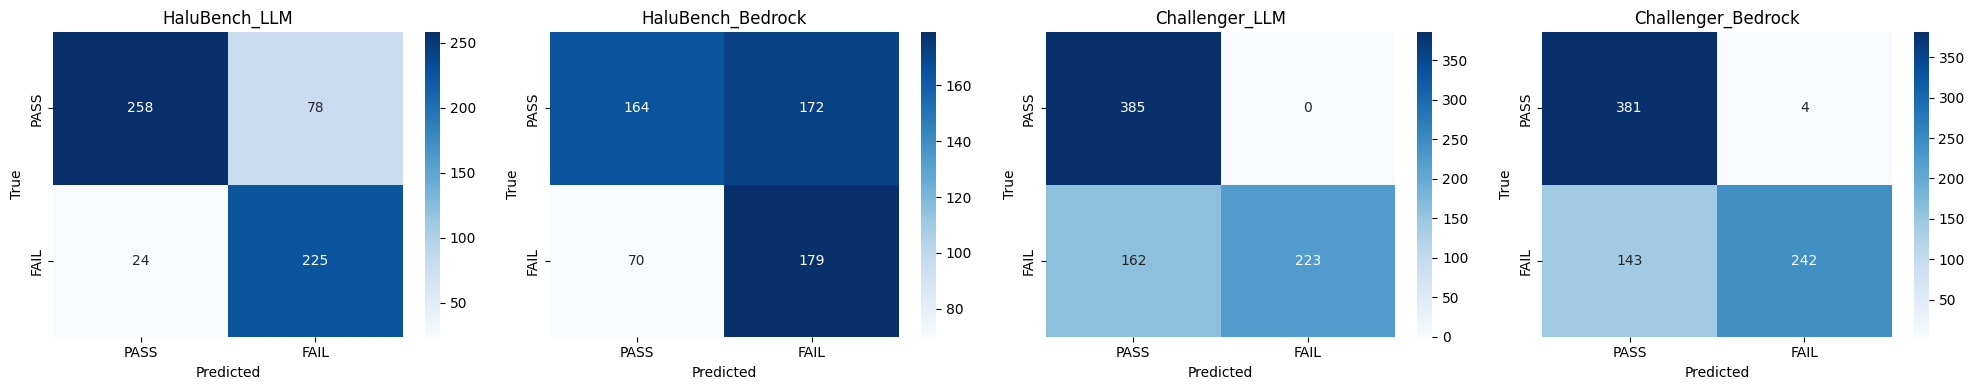

        Dataset_Model  Accuracy  Precision_PASS  Recall_PASS  F1_PASS  \
0       HaluBench_LLM      0.83            0.91         0.77     0.83   
1   HaluBench_Bedrock      0.59            0.70         0.49     0.58   
2      Challenger_LLM      0.79            0.70         1.00     0.83   
3  Challenger_Bedrock      0.81            0.73         0.99     0.84   

   Precision_FAIL  Recall_FAIL  F1_FAIL  Macro_Precision  Macro_Recall  \
0            0.74         0.90     0.82             0.83          0.84   
1            0.51         0.72     0.60             0.61          0.60   
2            1.00         0.58     0.73             0.85          0.79   
3            0.98         0.63     0.77             0.86          0.81   

   Macro_F1  
0      0.83  
1      0.59  
2      0.78  
3      0.80  


In [ ]:
# Step 2: Evaluate and collect metrics
summary = []
confusion_matrices = {}

for name, df in processed_files.items():
    if df['label'].dtype == 'int' or pd.api.types.is_numeric_dtype(df['label']):
        df['label_true'] = df['label'].map({0: 'FAIL', 1: 'PASS'})
    else:
        df['label_true'] = df['label']  # already labeled

    y_true = df["label_true"]
    y_pred = df["prediction"]

    cm = confusion_matrix(y_true, y_pred, labels=["PASS", "FAIL"])
    confusion_matrices[name] = cm

    report = classification_report(y_true, y_pred, output_dict=True, labels=["PASS", "FAIL"])
    
    summary.append({
    "Dataset_Model": name,
    "Accuracy": report["accuracy"],
    "Precision_PASS": report["PASS"]["precision"],
    "Recall_PASS": report["PASS"]["recall"],
    "F1_PASS": report["PASS"]["f1-score"],
    "Precision_FAIL": report["FAIL"]["precision"],
    "Recall_FAIL": report["FAIL"]["recall"],
    "F1_FAIL": report["FAIL"]["f1-score"],
    "Macro_Precision": report["macro avg"]["precision"],
    "Macro_Recall": report["macro avg"]["recall"],
    "Macro_F1": report["macro avg"]["f1-score"]
})


# Step 3: Plot all confusion matrices in one row
fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(5 * len(confusion_matrices), 4))

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["PASS", "FAIL"], yticklabels=["PASS", "FAIL"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

# Step 4: Summary DataFrame
summary_df = pd.DataFrame(summary)
print(summary_df.round(2))



In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

halubench_llm_df = pd.read_csv("../results/halubench_llm_results.csv")
halubench_bedrock_df = pd.read_csv("../results/halubench_bedrock_results.csv")


In [ ]:
halubench_llm_df.rename(columns={"llm_score": "prediction"}, inplace=True)
halubench_llm_df["label"] = halubench_llm_df["label"].map({"FAIL": 0, "PASS": 1}) if halubench_llm_df["label"].dtype == object else halubench_llm_df["label"]
halubench_llm_df["prediction"] = halubench_llm_df["prediction"].map({"FAIL": 0, "PASS": 1}) if halubench_llm_df["prediction"].dtype == object else halubench_llm_df["prediction"]
halubench_llm_df 


,id,context,query,response,label,source_ds,source,prediction,llm_reasoning
0,26104577,The prognostic importance of extramedullary in...,Does waldenström macroglobulinemia with extram...,Yes. We show that extramedullary involvement a...,0,pubmedQA,halubench,0,The DOCUMENT states that EMWM patients had a s...
1,financebench_id_02656,128 \nConsolidated Statements of Operations\nY...,What is the FY2019 - FY2021 3 year average of ...,75.1%,0,FinanceBench,halubench,0,To calculate the COGS as a percentage of reven...
2,financebench_id_08319,PART II\nItem 8\n \n \nBALANCE SHEETS\n \n(In ...,We need to calculate a reasonable approximatio...,"$364,850.00",0,FinanceBench,halubench,0,The DOCUMENT provides the total assets for Mic...
3,12135,passage 1:1 Spray a baking sheet with butter f...,how to cook pollock?,"Based on the provided passages, here is how to...",1,RAGTruth,halubench,0,The ANSWER accurately summarizes the steps fro...
4,21442579,Intra-aortic balloon pump (IABP) is an establi...,Does intra-aortic balloon pump implantation af...,No. This study demonstrates that CABG with IAB...,1,pubmedQA,halubench,1,The DOCUMENT provides data on the survival rat...
...,...,...,...,...,...,...,...,...,...
580,financebench_id_05629,Table of Contents\n \n \nintel corporation\nco...,By relying on the line items plainly stated wi...,5.7%,1,FinanceBench,halubench,1,The DOCUMENT provides Intel's net revenue for ...
581,9555b283-c5a8-467a-b0bd-84ca6bdd54c0,Hoping to rebound from their home loss to the...,Who got the Cardinals their first points of th...,Anquan Boldin,0,DROP,halubench,0,The DOCUMENT states that the Cardinals scored ...
582,financebench_id_05288,"SQUARE,INC.\nCONSOLIDATEDSTATEMENTSOFOPERATION...",We need to calculate a reasonable approximatio...,-4.5%,1,FinanceBench,halubench,1,The operating income (or loss) for each year i...
583,15838438,To determine which of the eye's refractive com...,Is high myopia associated with retinopathy of ...,Yes. High myopia associated with ROP appears p...,0,pubmedQA,halubench,0,"The DOCUMENT states that in ROP eyes, increasi..."


In [ ]:
halubench_bedrock_df.rename(columns={"bedrock_action": "prediction"}, inplace=True)
halubench_bedrock_df["prediction"] = halubench_bedrock_df["prediction"].apply(lambda x: 1 if x == "NONE" else 0)
halubench_bedrock_df

,id,context,query,response,label,source_ds,source,prediction,grounding_score,grounding_threshold,grounding_decision_reason,blocked_output_text
0,26104577,The prognostic importance of extramedullary in...,Does waldenström macroglobulinemia with extram...,Yes. We show that extramedullary involvement a...,0,pubmedQA,halubench,0,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
1,financebench_id_02656,128 \nConsolidated Statements of Operations\nY...,What is the FY2019 - FY2021 3 year average of ...,75.1%,0,FinanceBench,halubench,1,NaN,NaN,NaN,NaN
2,financebench_id_08319,PART II\nItem 8\n \n \nBALANCE SHEETS\n \n(In ...,We need to calculate a reasonable approximatio...,"$364,850.00",0,FinanceBench,halubench,0,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
3,12135,passage 1:1 Spray a baking sheet with butter f...,how to cook pollock?,"Based on the provided passages, here is how to...",1,RAGTruth,halubench,1,NaN,NaN,NaN,NaN
4,21442579,Intra-aortic balloon pump (IABP) is an establi...,Does intra-aortic balloon pump implantation af...,No. This study demonstrates that CABG with IAB...,1,pubmedQA,halubench,0,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
...,...,...,...,...,...,...,...,...,...,...,...,...
580,financebench_id_05629,Table of Contents\n \n \nintel corporation\nco...,By relying on the line items plainly stated wi...,5.7%,1,FinanceBench,halubench,0,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
581,9555b283-c5a8-467a-b0bd-84ca6bdd54c0,Hoping to rebound from their home loss to the...,Who got the Cardinals their first points of th...,Anquan Boldin,0,DROP,halubench,0,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
582,financebench_id_05288,"SQUARE,INC.\nCONSOLIDATEDSTATEMENTSOFOPERATION...",We need to calculate a reasonable approximatio...,-4.5%,1,FinanceBench,halubench,0,NaN,NaN,NaN,"Sorry, the model cannot answer this question."
583,15838438,To determine which of the eye's refractive com...,Is high myopia associated with retinopathy of ...,Yes. High myopia associated with ROP appears p...,0,pubmedQA,halubench,0,NaN,NaN,NaN,"Sorry, the model cannot answer this question."


In [ ]:

# Preprocess function to convert labels/predictions and evaluate by source_ds
def evaluate_by_source(df, model_label):
    results = []
    for name, group in df.groupby("source_ds"):
        y_true = group["label"]
        y_pred = group["prediction"]
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        results.append({
            "Source_DS": name,
            "Model": model_label,
            "Accuracy": report["accuracy"],
            "Precision_PASS": report["1"]["precision"],
            "Recall_PASS": report["1"]["recall"],
            "F1_PASS": report["1"]["f1-score"],
            "Precision_FAIL": report["0"]["precision"],
            "Recall_FAIL": report["0"]["recall"],
            "F1_FAIL": report["0"]["f1-score"],
            "Macro_Precision": report["macro avg"]["precision"],
            "Macro_Recall": report["macro avg"]["recall"],
            "Macro_F1": report["macro avg"]["f1-score"],
            "Support": len(group)
        })
    return pd.DataFrame(results)

# Run for both datasets
llm_results = evaluate_by_source(halubench_llm_df, "LLM")
bedrock_results = evaluate_by_source(halubench_bedrock_df, "Bedrock")

# Combine and display
combined_results = pd.concat([llm_results, bedrock_results], ignore_index=True)

combined_results

,Source_DS,Model,Accuracy,Precision_PASS,Recall_PASS,F1_PASS,Precision_FAIL,Recall_FAIL,F1_FAIL,Macro_Precision,Macro_Recall,Macro_F1,Support
0,DROP,LLM,0.823944,0.852459,0.764706,0.806202,0.802469,0.878378,0.838710,0.827464,0.821542,0.822456,142
1,FinanceBench,LLM,0.848315,0.931507,0.755556,0.834356,0.790476,0.943182,0.860104,0.860992,0.849369,0.847230,178
2,RAGTruth,LLM,0.848000,0.919192,0.892157,0.905473,0.576923,0.652174,0.612245,0.748057,0.772165,0.758859,125
3,pubmedQA,LLM,0.778571,0.959184,0.618421,0.752000,0.681319,0.968750,0.800000,0.820251,0.793586,0.776000,140
4,DROP,Bedrock,0.478873,0.434783,0.294118,0.350877,0.500000,0.648649,0.564706,0.467391,0.471383,0.457792,142
5,FinanceBench,Bedrock,0.505618,0.522727,0.255556,0.343284,0.500000,0.761364,0.603604,0.511364,0.508460,0.473444,178
6,RAGTruth,Bedrock,0.808000,0.914894,0.843137,0.877551,0.483871,0.652174,0.555556,0.699382,0.747656,0.716553,125
7,pubmedQA,Bedrock,0.600000,0.700000,0.460526,0.555556,0.544444,0.765625,0.636364,0.622222,0.613076,0.595960,140


In [ ]:
summary_df.to_csv("../results/results_summary_v1.csv", index=False)
fig.savefig("../results/confusion_matrices1.png")

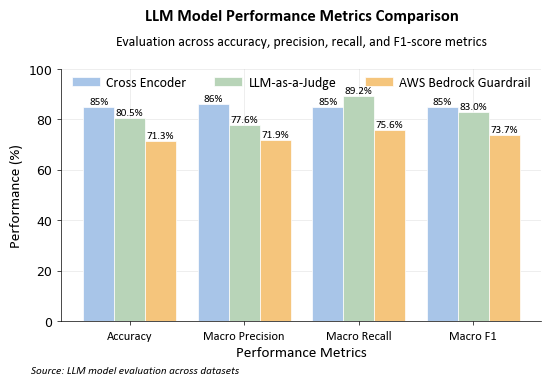

Font Size Settings:
Title: 12pt (bold)
Subtitle: 10pt (normal weight)
Axis labels: 11pt
Data labels: 8pt
Legend: 9pt


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure optimized for ACL single column format
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, 4))

# Data for the chart
categories = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
cross_encoder = [85, 86, 85, 85]
llm_judge = [80.5,	77.6,	89.2,	83.0]
aws_bedrock = [	71.3,	71.9,	75.6,	73.7]   

colors = {
    'cross_encoder': '#A8C5E8',   # Soft powder blue
    'llm_judge': '#B8D4B8',       # Gentle sage green
    'aws_bedrock': '#F5C57C'      # Light peach orange
}

# Set up bar positions - slightly wider bars for single column
x = np.arange(len(categories))
width = 0.27

# Create bars
bars1 = ax.bar(x - width, cross_encoder, width, label='Cross Encoder', 
               color=colors['cross_encoder'], edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x, llm_judge, width, label='LLM-as-a-Judge', 
               color=colors['llm_judge'], edgecolor='white', linewidth=0.5)
bars3 = ax.bar(x + width, aws_bedrock, width, label='AWS Bedrock Guardrail', 
               color=colors['aws_bedrock'], edgecolor='white', linewidth=0.5)

# Add data labels on bars
def add_data_labels(bars, data):
    for bar, value in zip(bars, data):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{value}%', ha='center', va='bottom', 
                fontsize=8, fontfamily='Calibri', fontweight='normal')

add_data_labels(bars1, cross_encoder)
add_data_labels(bars2, llm_judge)
add_data_labels(bars3, aws_bedrock)

# Font size variables for easy adjustment
title_fontsize = 12
subtitle_fontsize = 10

# Professional styling optimized for ACL format
ax.set_xlabel('Performance Metrics', fontfamily='Calibri', fontsize=11, fontweight='normal')
ax.set_ylabel('Performance (%)', fontfamily='Calibri', fontsize=11, fontweight='normal')

# Main title (bold)
ax.set_title('LLM Model Performance Metrics Comparison', 
             fontfamily='Calibri', fontsize=title_fontsize, fontweight='bold', pad=35)

# Subtitle (not bold) - positioned below the main title
ax.text(0.5, 1.08, 'Evaluation across accuracy, precision, recall, and F1-score metrics', 
        transform=ax.transAxes, fontfamily='Calibri', fontsize=subtitle_fontsize, 
        fontweight='normal', ha='center', va='bottom')

# Set y-axis limits and ticks (adjusted for better spacing)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))

# Set x-axis with better spacing for ACL format
ax.set_xticks(x)
ax.set_xticklabels(categories, fontfamily='Calibri', fontsize=10, rotation=0)

# Adjust spacing between category labels for better readability
plt.setp(ax.get_xticklabels(), ha='center')

# Add grid for readability
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Legend positioned at top of graph - no box, better spacing (adjusted for subtitle)
legend = ax.legend(loc='upper center', frameon=False, 
                  fontsize=9, prop={'family': 'Calibri'}, bbox_to_anchor=(0.5, 1.02),
                  ncol=3, columnspacing=2.0, handletextpad=0.5)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Add source attribution - positioned with better spacing
plt.figtext(0.1, 0.02, 'Source: LLM model evaluation across datasets', 
            fontsize=8, fontfamily='Calibri', style='italic')

# Set all tick parameters for ACL format
ax.tick_params(axis='both', which='major', labelsize=9, 
               colors='black', width=0.5, length=3)

# Adjust layout for proper spacing with title, subtitle, and top legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.78, left=0.15, right=0.95)

# Save the figure optimized for ACL paper
plt.savefig('acl_performance_metrics.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig('acl_performance_metrics.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

# Display the chart
plt.show()


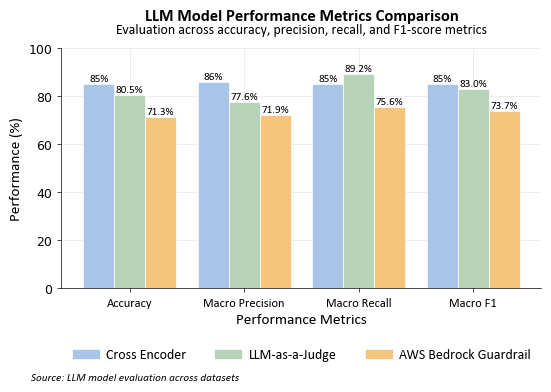

Font Size Settings:
Title: 12pt (bold)
Subtitle: 10pt (normal weight)
Axis labels: 11pt
Data labels: 8pt
Legend: 9pt


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure optimized for ACL single column format
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, 4))

# Data for the chart
categories = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
cross_encoder = [85, 86, 85, 85]
llm_judge = [80.5,	77.6,	89.2,	83.0]
aws_bedrock = [	71.3,	71.9,	75.6,	73.7]   

colors = {
    'cross_encoder': '#A8C5E8',   # Soft powder blue
    'llm_judge': '#B8D4B8',       # Gentle sage green
    'aws_bedrock': '#F5C57C'      # Light peach orange
}

# Set up bar positions - slightly wider bars for single column
x = np.arange(len(categories))
width = 0.27

# Create bars
bars1 = ax.bar(x - width, cross_encoder, width, label='Cross Encoder', 
               color=colors['cross_encoder'], edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x, llm_judge, width, label='LLM-as-a-Judge', 
               color=colors['llm_judge'], edgecolor='white', linewidth=0.5)
bars3 = ax.bar(x + width, aws_bedrock, width, label='AWS Bedrock Guardrail', 
               color=colors['aws_bedrock'], edgecolor='white', linewidth=0.5)

# Add data labels on bars
def add_data_labels(bars, data):
    for bar, value in zip(bars, data):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{value}%', ha='center', va='bottom', 
                fontsize=8, fontfamily='Calibri', fontweight='normal')

add_data_labels(bars1, cross_encoder)
add_data_labels(bars2, llm_judge)
add_data_labels(bars3, aws_bedrock)

# Font size variables for easy adjustment
title_fontsize = 12
subtitle_fontsize = 10

# Professional styling optimized for ACL format
ax.set_xlabel('Performance Metrics', fontfamily='Calibri', fontsize=11, fontweight='normal')
ax.set_ylabel('Performance (%)', fontfamily='Calibri', fontsize=11, fontweight='normal')

# Main title (bold)
ax.set_title('LLM Model Performance Metrics Comparison', 
             fontfamily='Calibri', fontsize=title_fontsize, fontweight='bold', pad=20)

# Subtitle (not bold) - positioned below the main title
ax.text(0.5, 1.05, 'Evaluation across accuracy, precision, recall, and F1-score metrics', 
        transform=ax.transAxes, fontfamily='Calibri', fontsize=subtitle_fontsize, 
        fontweight='normal', ha='center', va='bottom')

# Set y-axis limits and ticks (adjusted for better spacing)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))

# Set x-axis with better spacing for ACL format
ax.set_xticks(x)
ax.set_xticklabels(categories, fontfamily='Calibri', fontsize=10, rotation=0)

# Adjust spacing between category labels for better readability
plt.setp(ax.get_xticklabels(), ha='center')

# Add grid for readability
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Legend positioned below the x-axis
legend = ax.legend(loc='upper center', frameon=False, 
                  fontsize=9, prop={'family': 'Calibri'}, bbox_to_anchor=(0.5, -0.20),
                  ncol=3, columnspacing=2.0, handletextpad=0.5)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Add source attribution - positioned with better spacing (moved down to accommodate legend)
plt.figtext(0.1, 0.02, 'Source: LLM model evaluation across datasets', 
            fontsize=8, fontfamily='Calibri', style='italic')

# Set all tick parameters for ACL format
ax.tick_params(axis='both', which='major', labelsize=9, 
               colors='black', width=0.5, length=3)

# Adjust layout for proper spacing with legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.25, top=0.85, left=0.15, right=0.95)

# Save the figure optimized for ACL paper
plt.savefig('acl_performance_metrics.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig('acl_performance_metrics.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

# Display the chart
plt.show()

# Optional: Print font size settings for easy reference
print("Font Size Settings:")
print(f"Title: {title_fontsize}pt (bold)")
print(f"Subtitle: {subtitle_fontsize}pt (normal weight)")
print(f"Axis labels: 11pt")
print(f"Data labels: 8pt")
print(f"Legend: 9pt")

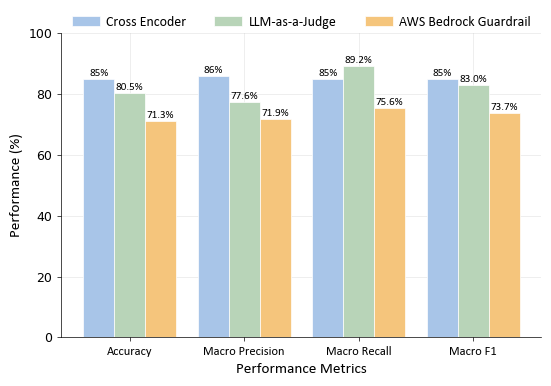

Font Size Settings:
Axis labels: 11pt
Data labels: 8pt
Legend: 9pt


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure optimized for ACL single column format
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, 4))

# Data for the chart
categories = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
cross_encoder = [85, 86, 85, 85]
llm_judge = [80.5,	77.6,	89.2,	83.0]
aws_bedrock = [	71.3,	71.9,	75.6,	73.7]   

colors = {
    'cross_encoder': '#A8C5E8',   # Soft powder blue
    'llm_judge': '#B8D4B8',       # Gentle sage green
    'aws_bedrock': '#F5C57C'      # Light peach orange
}

# Set up bar positions - slightly wider bars for single column
x = np.arange(len(categories))
width = 0.27

# Create bars
bars1 = ax.bar(x - width, cross_encoder, width, label='Cross Encoder', 
               color=colors['cross_encoder'], edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x, llm_judge, width, label='LLM-as-a-Judge', 
               color=colors['llm_judge'], edgecolor='white', linewidth=0.5)
bars3 = ax.bar(x + width, aws_bedrock, width, label='AWS Bedrock Guardrail', 
               color=colors['aws_bedrock'], edgecolor='white', linewidth=0.5)

# Add data labels on bars
def add_data_labels(bars, data):
    for bar, value in zip(bars, data):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{value}%', ha='center', va='bottom', 
                fontsize=8, fontfamily='Calibri', fontweight='normal')

add_data_labels(bars1, cross_encoder)
add_data_labels(bars2, llm_judge)
add_data_labels(bars3, aws_bedrock)

# Professional styling optimized for ACL format
ax.set_xlabel('Performance Metrics', fontfamily='Calibri', fontsize=11, fontweight='normal')
ax.set_ylabel('Performance (%)', fontfamily='Calibri', fontsize=11, fontweight='normal')

# Set y-axis limits and ticks (adjusted for better spacing)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))

# Set x-axis with better spacing for ACL format
ax.set_xticks(x)
ax.set_xticklabels(categories, fontfamily='Calibri', fontsize=10, rotation=0)

# Adjust spacing between category labels for better readability
plt.setp(ax.get_xticklabels(), ha='center')

# Add grid for readability
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Legend positioned at the top
legend = ax.legend(loc='upper center', frameon=False, 
                  fontsize=9, prop={'family': 'Calibri'}, bbox_to_anchor=(0.5, 1.1),
                  ncol=3, columnspacing=2.0, handletextpad=0.5)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Add source attribution - positioned with better spacing
#plt.figtext(0.1, 0.02, 'Source: LLM model evaluation across datasets', 
#            fontsize=8, fontfamily='Calibri', style='italic')

# Set all tick parameters for ACL format
ax.tick_params(axis='both', which='major', labelsize=9, 
               colors='black', width=0.5, length=3)

# Adjust layout for proper spacing with legend at top
plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.88, left=0.15, right=0.95)

# Save the figure optimized for ACL paper
plt.savefig('acl_performance_metrics.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig('acl_performance_metrics.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

# Display the chart
plt.show()

# Optional: Print font size settings for easy reference
print("Font Size Settings:")
print(f"Axis labels: 11pt")
print(f"Data labels: 8pt")
print(f"Legend: 9pt")

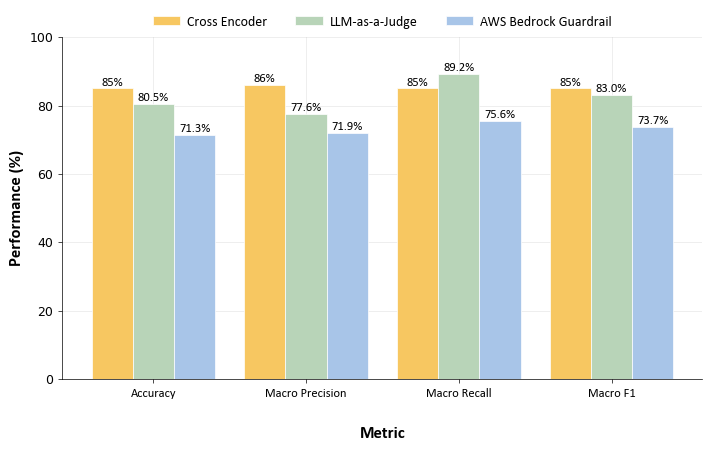

Font Size Settings:
Axis labels: 11pt
Data labels: 8pt
Legend: 9pt


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure optimized for ACL single column format - made wider
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 4.5))

# Data for the chart
categories = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
cross_encoder = [85, 86, 85, 85]
llm_judge = [80.5,	77.6,	89.2,	83.0]
aws_bedrock = [	71.3,	71.9,	75.6,	73.7]   

colors = {
    'cross_encoder': "#F7C761",   # Deeper powder blue (less washed out)
    'llm_judge':  '#B8D4B8',       # Deeper sage green (less washed out)
    'aws_bedrock': '#A8C5E8' # Brighter sandy orange
}

# Set up bar positions - slightly wider bars for single column
x = np.arange(len(categories))
width = 0.27

# Create bars
bars1 = ax.bar(x - width, cross_encoder, width, label='Cross Encoder', 
               color=colors['cross_encoder'], edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x, llm_judge, width, label='LLM-as-a-Judge', 
               color=colors['llm_judge'], edgecolor='white', linewidth=0.5)
bars3 = ax.bar(x + width, aws_bedrock, width, label='AWS Bedrock Guardrail', 
               color=colors['aws_bedrock'], edgecolor='white', linewidth=0.5)

# Add data labels on bars
def add_data_labels(bars, data):
    for bar, value in zip(bars, data):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{value}%', ha='center', va='bottom', 
                fontsize=9, fontfamily='Calibri', fontweight='normal')

add_data_labels(bars1, cross_encoder)
add_data_labels(bars2, llm_judge)
add_data_labels(bars3, aws_bedrock)

# Professional styling optimized for ACL format
ax.set_xlabel('Metric', fontfamily='Calibri', fontsize=12, fontweight='bold',labelpad=20)
ax.set_ylabel('Performance (%)', fontfamily='Calibri', fontsize=12, fontweight='bold')

# Set y-axis limits and ticks (adjusted for better spacing)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))

# Set x-axis with better spacing for ACL format
ax.set_xticks(x)
ax.set_xticklabels(categories, fontfamily='Calibri', fontsize=11, rotation=0)

# Adjust spacing between category labels for better readability
plt.setp(ax.get_xticklabels(), ha='center')

# Add grid for readability
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Legend positioned at the top
legend = ax.legend(loc='upper center', frameon=False, 
                  fontsize=9, prop={'family': 'Calibri'}, bbox_to_anchor=(0.5, 1.1),
                  ncol=3, columnspacing=2.0, handletextpad=0.5)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)


# Set all tick parameters for ACL format
ax.tick_params(axis='both', which='major', labelsize=9, 
               colors='black', width=0.5, length=3)

# Adjust layout for proper spacing with legend at top
plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.88, left=0.15, right=0.95)

# Save the figure optimized for ACL paper
plt.savefig('acl_performance_metrics.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig('acl_performance_metrics.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

# Display the chart
plt.show()

# Optional: Print font size settings for easy reference
print("Font Size Settings:")
print(f"Axis labels: 11pt")
print(f"Data labels: 8pt")
print(f"Legend: 9pt")